# Botan Post-Quantum Signature Algorithm Performance Analysis

This Jupyter Notebook offers a comprehensive performance evaluation of Post-Quantum Cryptography (**PQC**) digital signature mechanisms implemented in the Botan cryptography library. The notebook precisely measures **key generation times, the crucial time taken for signing messages, and the time for verifying those signatures**. Additionally, it quantifies the sizes of public keys, private keys, and signatures across different security levels. All collected data is clearly presented in tables and charts. The primary objective is to assess the practical applicability of these post-quantum signature algorithms based on their real-world performance characteristics.
![Signature Scheme](https://www.researchgate.net/profile/Ouail-Ouchetto/publication/358802566/figure/fig1/AS:1126646925017090@1645624967748/Public-key-digital-signature-scheme-Alice-uses-her-private-key-to-sign-her-messages-Bob.png)

## Table of Contents
- [Requirements](#requirements)
- [Code](#code)
- [Output](#output)
    - [Level 1](#l1)
    - [Level 2](#l2)
    - [Level 3](#l3)
- [Conclusion](#conclusion)

## Requirements <a id="requirements"></a>

In [1]:
import sys
!"{sys.executable}" -m pip install -q -r requirements.txt

In [2]:
# Requirements 
import os
import sys
import timeit
import pandas as pd
import ctypes
import matplotlib.pyplot as plt
import seaborn as sns

# Load Botan
current_dir = os.getcwd()
os.environ['PATH'] = current_dir + os.pathsep + os.environ['PATH']
sys.path.append(current_dir)
#dll_path for Windows "botan-3.dll"
dll_path = os.path.join(current_dir, "libbotan-3.so.10") #for Linux
botan_dll = ctypes.CDLL(dll_path)
import botan3 as botan

In [3]:
# Panda options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Definitions

signature_L1 = ["Dilithium-4x4",  # Equivalent to ML-DSA-44 (NIST Level 2)
                "XMSS"]          # Using default parameters

signature_L3 = ["Dilithium-6x5"] # Equivalent to ML-DSA-65 (NIST Level 3)
# Note: XMSS and HSS-LMS don't have specific L3 parameter sets in Botan's implementation
# They use default parameters that are generally considered L1 or L5

signature_L5 = ["Dilithium-8x7", # Equivalent to ML-DSA-87 (NIST Level 5)
                "HSS-LMS"]       # Using default parameters

# For comparison with classical algorithms
classical_algorithms = ["RSA", "ECDSA", "Ed25519"]

signature_L1.extend(classical_algorithms)
signature_L3.extend(classical_algorithms)
signature_L5.extend(classical_algorithms)

test_runs = 100
message = "This is the message to sign"

**Notes on the Post-Quantum Algorithms:**

We are testing several post-quantum signature algorithms that are supported in Botan, along with traditional signature algorithms for comparison:

**Post-Quantum Algorithms:**
- **Dilithium**: A lattice-based signature scheme that has been standardized by NIST as ML-DSA (FIPS 204). We're testing three parameter sets:
  - **Dilithium-4x4**: Equivalent to ML-DSA-44 (NIST security level 2)
  - **Dilithium-6x5**: Equivalent to ML-DSA-65 (NIST security level 3)
  - **Dilithium-8x7**: Equivalent to ML-DSA-87 (NIST security level 5)

- **XMSS**: eXtended Merkle Signature Scheme, a stateful hash-based signature scheme. "Stateful" means the private key changes after each signature, requiring careful key management. Botan implements XMSS with default parameters that correspond to NIST security level 1.

- **HSS-LMS**: Hierarchical Signature System with Leighton-Micali Signatures, another stateful hash-based signature scheme standardized in RFC 8554. Botan implements HSS-LMS with default parameters that correspond to NIST security level 5.

**Why no XMSS or HSS-LMS at Level 3?**
The Botan implementation of XMSS and HSS-LMS doesn't provide specific parameter sets for security level 3. The hash-based signature schemes typically come with predefined parameter sets that correspond to specific security levels. In Botan, the default XMSS parameters are suitable for level 1, while HSS-LMS parameters are suitable for level 5.

**Traditional Algorithms (for comparison):**
- **RSA**: The classic public key cryptosystem that can be used for both encryption and signatures
- **ECDSA**: Elliptic Curve Digital Signature Algorithm, offering smaller key sizes than RSA
- **Ed25519**: An Edwards-curve Digital Signature Algorithm offering high performance and security

Including both post-quantum and traditional algorithms allows us to compare their performance characteristics directly.

## Code <a id="code"></a>

In [4]:
# Functions

def generate_keys(algorithm, security_level):
    params = ""
    if algorithm == "RSA":
        params = "2048"
    elif algorithm == "ECDSA":
        params = "secp256r1"
    
    rng = botan.RandomNumberGenerator()
    private_key = botan.PrivateKey.create(algorithm, params, rng)
    public_key = private_key.get_public_key()
    
    # Handle public key export
    try:
        public_key_bin = public_key.to_raw()
        public_key_hex = public_key_bin.hex()
        public_key_len = len(public_key_bin)
    except:
        public_key_hex = "Public key raw export not supported"
        public_key_len = 0
    
    # Handle private key export
    try:
        private_key_bin = private_key.to_raw()
        private_key_hex = private_key_bin.hex()
        private_key_len = len(private_key_bin)
    except:
        private_key_hex = "Private key raw export not supported"
        private_key_len = 0
    
    return { 'Algorithm': algorithm, 'Security Level': security_level,
        'Public Key (hex)': public_key_hex, 'Public Key length': public_key_len,
        'Secret Key (hex)': private_key_hex, 'Secret Key length': private_key_len}, private_key


def sign_message(algorithm, security_level, message, private_key):
    rng = botan.RandomNumberGenerator()
    
    padding = ""
    if "Dilithium" in algorithm:
        padding = ""
    elif algorithm == "RSA":
        padding = "EMSA-PKCS1-v1_5(SHA-256)"
    elif algorithm == "ECDSA":
        padding = "EMSA1(SHA-256)"
    elif algorithm == "Ed25519":
        padding = ""
    elif algorithm == "XMSS" or algorithm == "HSS-LMS":
        padding = ""
    
    signer = botan.PKSign(private_key, padding)
    signer.update(message)
    signature = signer.finish(rng)
    
    return { 'Algorithm': algorithm, 'Security Level': security_level,
        'Message (plain)': message, 'Message length': len(message),
        'Signature' : signature.hex(), 'Signature length' : len(signature)}, signature
    
def verify(algorithm, security_level, signature, message, public_key):
    padding = ""
    if "Dilithium" in algorithm:
        padding = ""
    elif algorithm == "RSA":
        padding = "EMSA-PKCS1-v1_5(SHA-256)"
    elif algorithm == "ECDSA":
        padding = "EMSA1(SHA-256)"
    elif algorithm == "Ed25519":
        padding = ""
    elif algorithm == "XMSS" or algorithm == "HSS-LMS":
        padding = ""
    
    verifier = botan.PKVerify(public_key, padding)
    verifier.update(message)
    is_valid = verifier.check_signature(signature)
    
    return { 'Algorithm': algorithm, 'Security Level': security_level, 'Is Valid' : is_valid}


def times_to_df(algorithm: str, execution_times: list, security_level: str, operation_type: str) -> pd.DataFrame:
    avg_time = sum(execution_times) / len(execution_times)
    min_time = min(execution_times)
    max_time = max(execution_times)

    data = {
        'Algorithm': [algorithm],
        'Security Level': [security_level],
        'Operation': [operation_type],
        'Min_Time (s)': [min_time], 
        'Average_Time (s)': [avg_time],
        'Max_Time (s)': [max_time] 
    }

    return pd.DataFrame(data)


def measure_execution_times(func, num_runs, *func_args):
    times = timeit.repeat(lambda: func(*func_args), number=1, repeat=num_runs)
    return times



def process_signing_level(algorithms_list: list, runs: int, level_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    keys_data_list = []
    key_times_list = []
    signing_data_list = []
    signing_times_list = []
    verify_data_list = []
    verify_times_list = []

    for alg in algorithms_list:
        keys_info, private_key = generate_keys(alg, level_name)
        keys_data_list.append(keys_info)

        times_keys = measure_execution_times(generate_keys, runs, alg, level_name)
        time_df_keys = times_to_df(alg, times_keys, level_name, "Key Generation")
        key_times_list.append(time_df_keys)
        
        # Get the public key from the private key
        public_key = private_key.get_public_key()

        # Sign message and measure time
        signing_data, signature = sign_message(alg, level_name, message, private_key)
        signing_data_list.append(signing_data)
        
        times_signing = measure_execution_times(sign_message, runs, alg, level_name, message, private_key)
        time_df_signing = times_to_df(alg, times_signing, level_name, "Signing")
        signing_times_list.append(time_df_signing)

        # Verify signature and measure time
        verify_data = verify(alg, level_name, signature, message, public_key)
        verify_data_list.append(verify_data)
        
        times_verify = measure_execution_times(verify, runs, alg, level_name, signature, message, public_key)
        time_df_verify = times_to_df(alg, times_verify, level_name, "Verify")
        verify_times_list.append(time_df_verify)

    # Create DataFrames from the collected data
    df_keys = pd.DataFrame(keys_data_list)
    df_time_keys = pd.concat(key_times_list, ignore_index=True)
    df_signing = pd.DataFrame(signing_data_list)
    df_time_signing = pd.concat(signing_times_list, ignore_index=True)
    df_verify = pd.DataFrame(verify_data_list)
    df_time_verify = pd.concat(verify_times_list, ignore_index=True)

    return df_keys, df_time_keys, df_signing, df_time_signing, df_verify, df_time_verify

In [5]:
# show Results

def display_results(level_name: str, df: pd.DataFrame, description: str):
    print(f"\n--- {description} ({level_name}) ---") 
    print(df)

def plot_key_length_comparison(df_keys_all: pd.DataFrame, plot_type: str = 'keys'):
    # Check if DataFrame is empty
    if df_keys_all.empty:
        return
        
    # Check if required columns exist
    required_columns = ['Algorithm', 'Security Level']
    if plot_type == 'keys':
        value_vars_to_plot = ['Public Key length', 'Secret Key length']
        plot_title = 'Public and Secret Key Lengths in Bytes per Algorithm'
    elif plot_type == 'signature':
        value_vars_to_plot = ['Signature length']
        plot_title = 'Signature Lengths in Bytes per Algorithm'
    
    # Make sure all required columns exist
    for col in required_columns + value_vars_to_plot:
        if col not in df_keys_all.columns:
            return

    df_keys_all_melted = df_keys_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=value_vars_to_plot,
        var_name='Key Type',
        value_name='Length (Bytes)'
    )
    
    df_keys_all_melted_filtered = df_keys_all_melted[df_keys_all_melted['Length (Bytes)'] > 0].copy()

    level_order = ["L1", "L3", "L5", "Unknown"]

    df_keys_all_melted_filtered.loc[:, 'Security Level'] = pd.Categorical(
        df_keys_all_melted_filtered['Security Level'], categories=level_order, ordered=True)

    df_keys_all_melted_filtered = df_keys_all_melted_filtered.sort_values(['Security Level', 'Algorithm'])

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_keys_all_melted_filtered,
        x='Algorithm',
        y='Length (Bytes)',
        hue='Key Type' if plot_type == 'keys' else None
    )
    plt.title(plot_title)
    plt.xlabel('Algorithm')
    plt.ylabel('Length (Bytes)')
    plt.xticks(rotation=45, ha='right')
    if len(value_vars_to_plot) > 1:
        plt.legend(title='Key Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_timing_comparison(df_time_all: pd.DataFrame, runs: int, title_suffix: str, level: str): 
    # Check if DataFrame is empty
    if df_time_all.empty:
        return
        
    # Check if required columns exist
    required_columns = ['Algorithm', 'Security Level', 'Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']
    for col in required_columns:
        if col not in df_time_all.columns:
            return
    
    df_time_all_melted = df_time_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)'],
        var_name='Time Metric',
        value_name='Time (s)' 
    )

    level_order = ["L1", "L3", "L5", "Unknown"]
    df_time_all_melted.loc[:, 'Security Level'] = pd.Categorical(
        df_time_all_melted['Security Level'], categories=level_order, ordered=True
    )
    df_time_all_melted = df_time_all_melted.sort_values(
        ['Security Level', 'Algorithm']
    )

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_time_all_melted,
        x='Algorithm',
        y='Time (s)', 
        hue='Time Metric', 
    )
    plt.title(f'{title_suffix} Times per Algorithm (L{level}) (Min, Average, Max over {runs} Runs)') 
    plt.xlabel('Algorithm') 
    plt.ylabel('Time (s) (Log Scale)') 
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Time Metric', bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

## Output <a id="ouput"></a>

### Level 1 <a id="l1"></a>

In [6]:
print("\nLevel 1...")
df_keys_L1, df_time_keys_L1, df_signing_L1,  df_time_signing_L1, df_verify_L1, df_time_verify_L1 = process_signing_level(signature_L1, test_runs, "L1")


Level 1...


In [7]:
display_results("L1", df_keys_L1, "Generated Keys")
display_results("L1", df_time_keys_L1, "Average Key Generation Times")


--- Generated Keys (L1) ---
       Algorithm Security Level  \
0  Dilithium-4x4             L1   
1           XMSS             L1   
2            RSA             L1   
3          ECDSA             L1   
4        Ed25519             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [8]:
display_results("L1", df_signing_L1, "Signing Data")
display_results("L1", df_time_signing_L1, "Average Signing Times")


--- Signing Data (L1) ---
       Algorithm Security Level              Message (plain)  Message length  \
0  Dilithium-4x4             L1  This is the message to sign              27   
1           XMSS             L1  This is the message to sign              27   
2            RSA             L1  This is the message to sign              27   
3          ECDSA             L1  This is the message to sign              27   
4        Ed25519             L1  This is the message to sign              27   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [9]:
display_results("L1", df_verify_L1, "Verify Data")
display_results("L1", df_time_verify_L1, "Average Verify Times")


--- Verify Data (L1) ---
       Algorithm Security Level  Is Valid
0  Dilithium-4x4             L1      True
1           XMSS             L1      True
2            RSA             L1      True
3          ECDSA             L1      True
4        Ed25519             L1      True

--- Average Verify Times (L1) ---
       Algorithm Security Level Operation  Min_Time (s)  Average_Time (s)  \
0  Dilithium-4x4             L1    Verify      0.000185          0.000270   
1           XMSS             L1    Verify      0.002180          0.002705   
2            RSA             L1    Verify      0.000045          0.000052   
3          ECDSA             L1    Verify      0.000151          0.000169   
4        Ed25519             L1    Verify      0.000109          0.000115   

   Max_Time (s)  
0      0.000447  
1      0.004937  
2      0.000383  
3      0.000573  
4      0.000343  


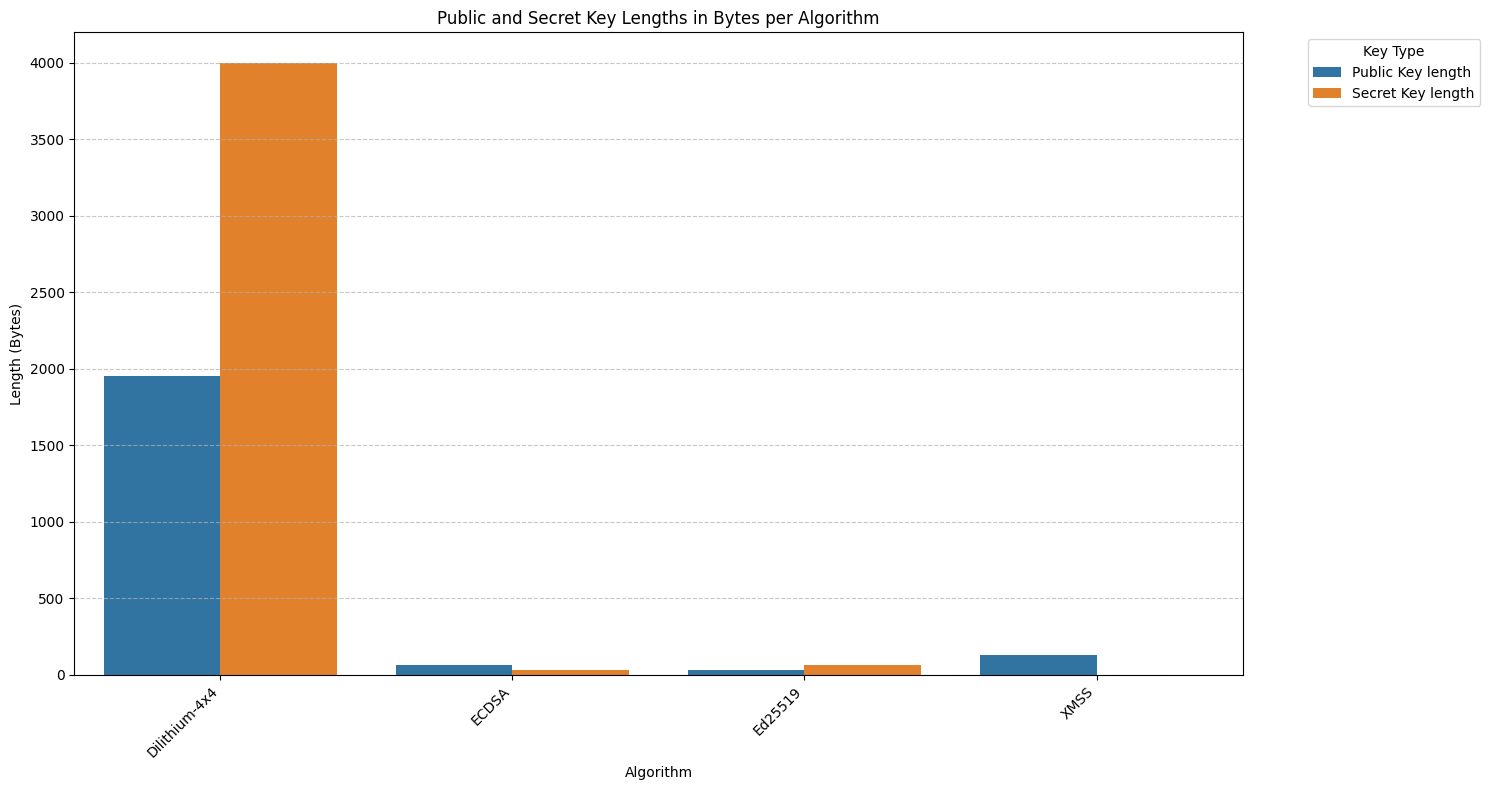

In [10]:
plot_key_length_comparison(df_keys_L1)

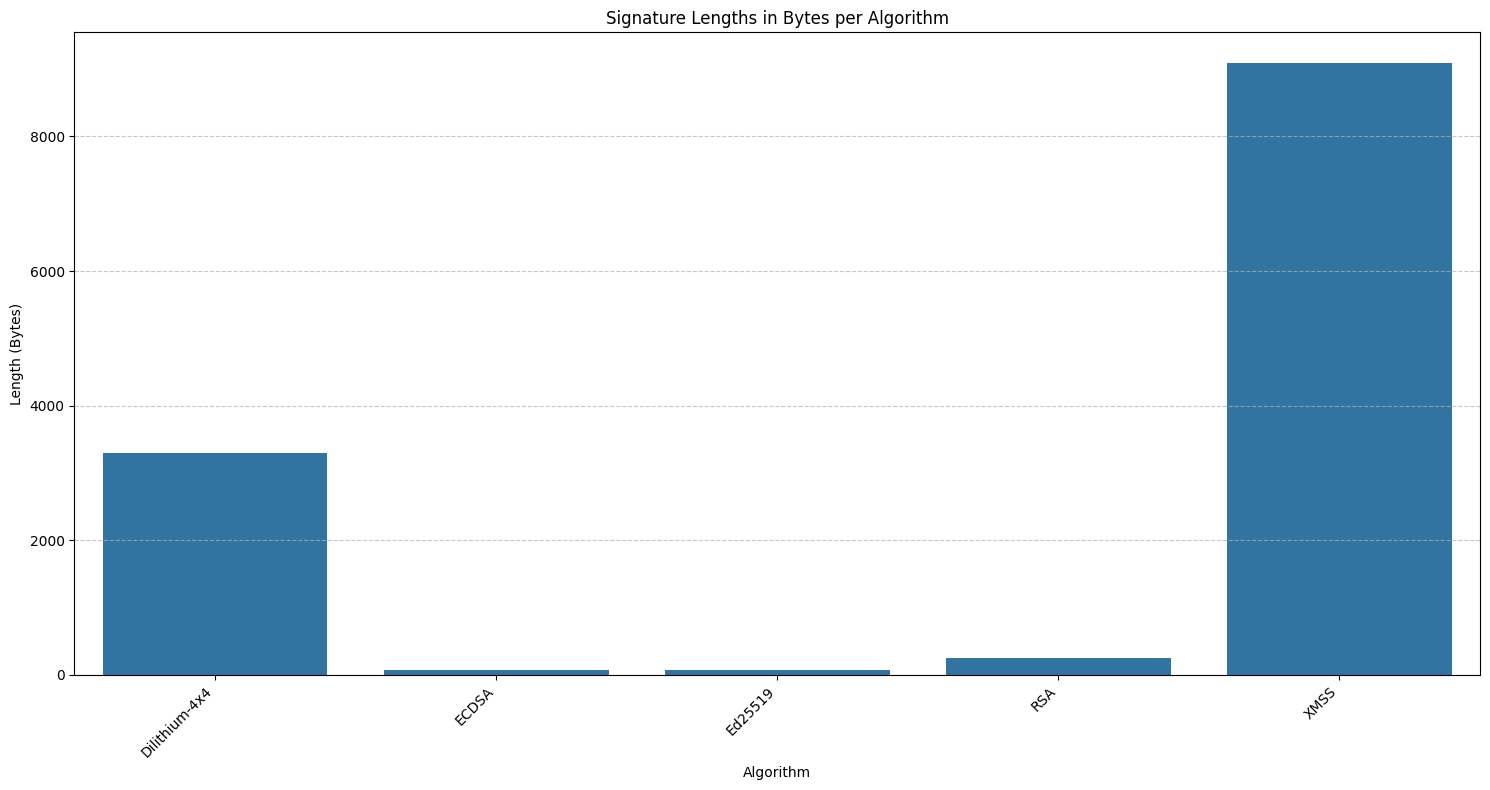

In [11]:
plot_key_length_comparison(df_signing_L1, "signature")

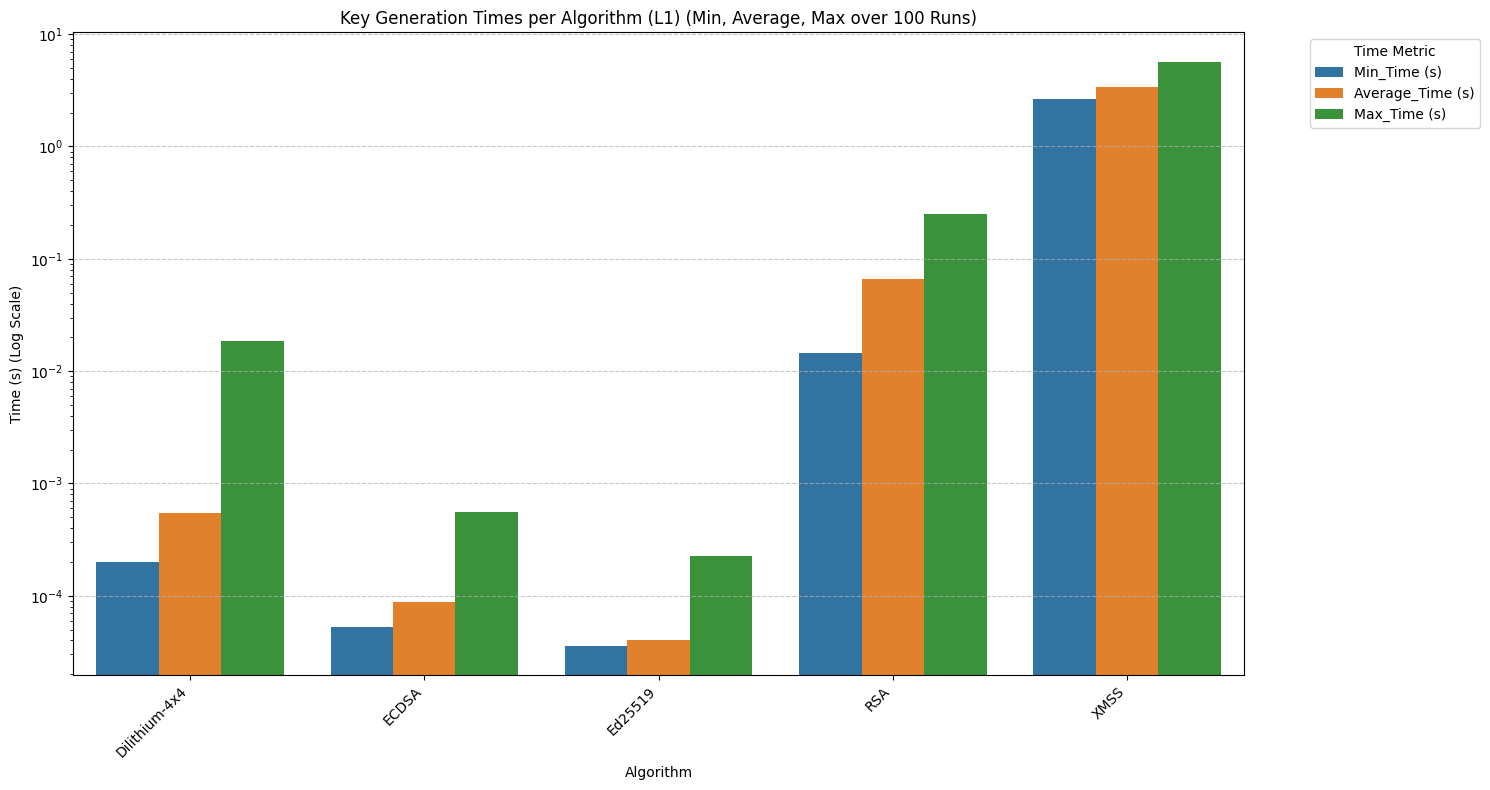

In [12]:
plot_timing_comparison(df_time_keys_L1, test_runs, "Key Generation", 1)

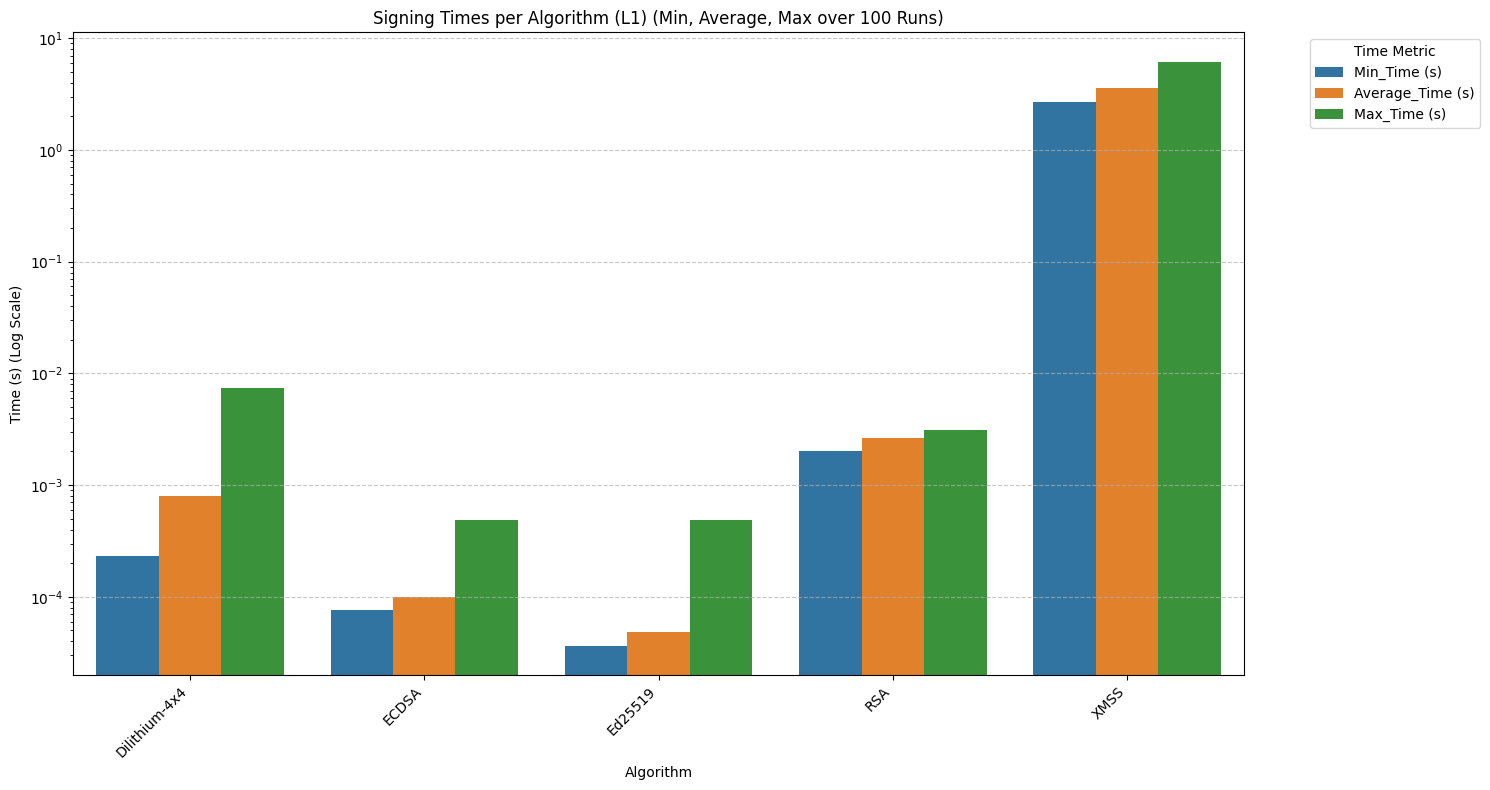

In [13]:
plot_timing_comparison(df_time_signing_L1, test_runs, "Signing", 1)

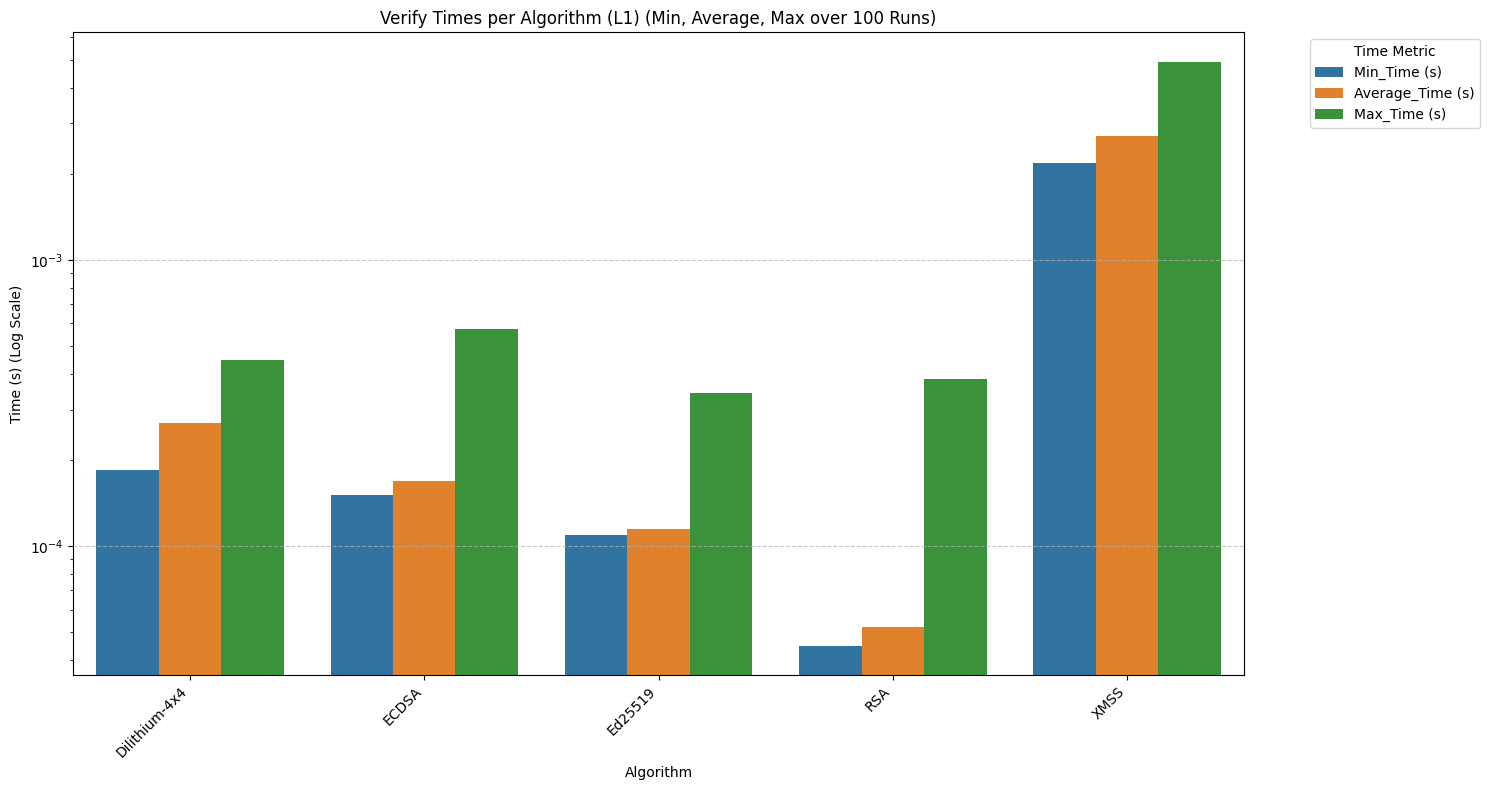

In [14]:
plot_timing_comparison(df_time_verify_L1, test_runs, "Verify", 1)

### Level 3 <a id="l3"></a>

In [15]:
print("\nLevel 3...")
df_keys_L3, df_time_keys_L3, df_signing_L3, df_time_signing_L3, df_verify_L3, df_time_verify_L3 = process_signing_level(signature_L3, test_runs, "L3")


Level 3...


In [16]:
display_results("L3", df_keys_L3, "Generated Keys")
display_results("L3", df_time_keys_L3, "Average Key Generation Times")


--- Generated Keys (L3) ---
       Algorithm Security Level  \
0  Dilithium-6x5             L3   
1            RSA             L3   
2          ECDSA             L3   
3        Ed25519             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [17]:
display_results("L3", df_signing_L3, "Signing Data")
display_results("L3", df_time_signing_L3, "Average Signing Times")


--- Signing Data (L3) ---
       Algorithm Security Level              Message (plain)  Message length  \
0  Dilithium-6x5             L3  This is the message to sign              27   
1            RSA             L3  This is the message to sign              27   
2          ECDSA             L3  This is the message to sign              27   
3        Ed25519             L3  This is the message to sign              27   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [18]:
display_results("L3", df_verify_L3, "Verify Data")
display_results("L3", df_time_verify_L3, "Average Verify Times")


--- Verify Data (L3) ---
       Algorithm Security Level  Is Valid
0  Dilithium-6x5             L3      True
1            RSA             L3      True
2          ECDSA             L3      True
3        Ed25519             L3      True

--- Average Verify Times (L3) ---
       Algorithm Security Level Operation  Min_Time (s)  Average_Time (s)  \
0  Dilithium-6x5             L3    Verify      0.000163          0.000202   
1            RSA             L3    Verify      0.000024          0.000027   
2          ECDSA             L3    Verify      0.000136          0.000151   
3        Ed25519             L3    Verify      0.000098          0.000109   

   Max_Time (s)  
0      0.000484  
1      0.000073  
2      0.000380  
3      0.000333  


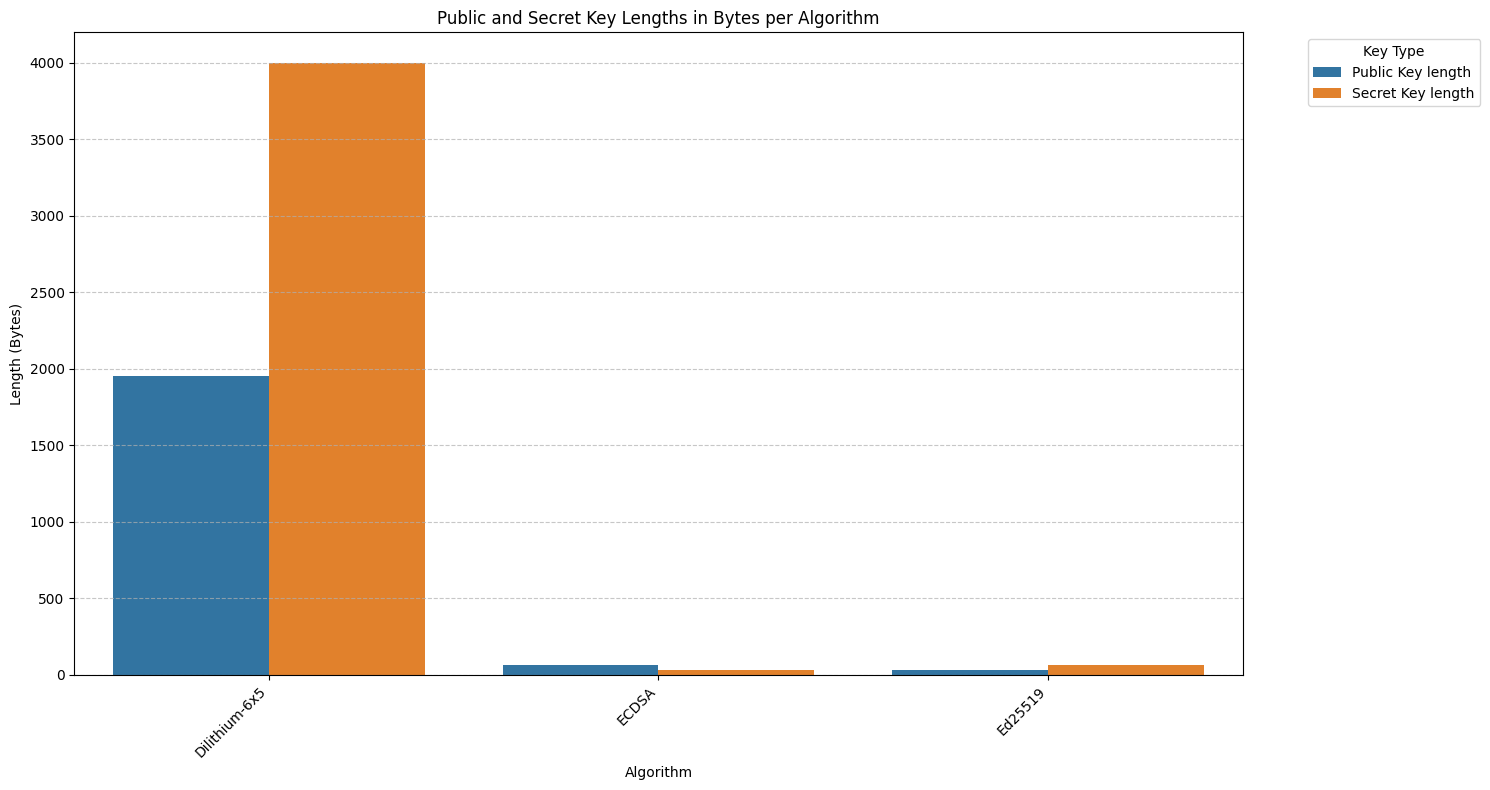

In [19]:
plot_key_length_comparison(df_keys_L3)

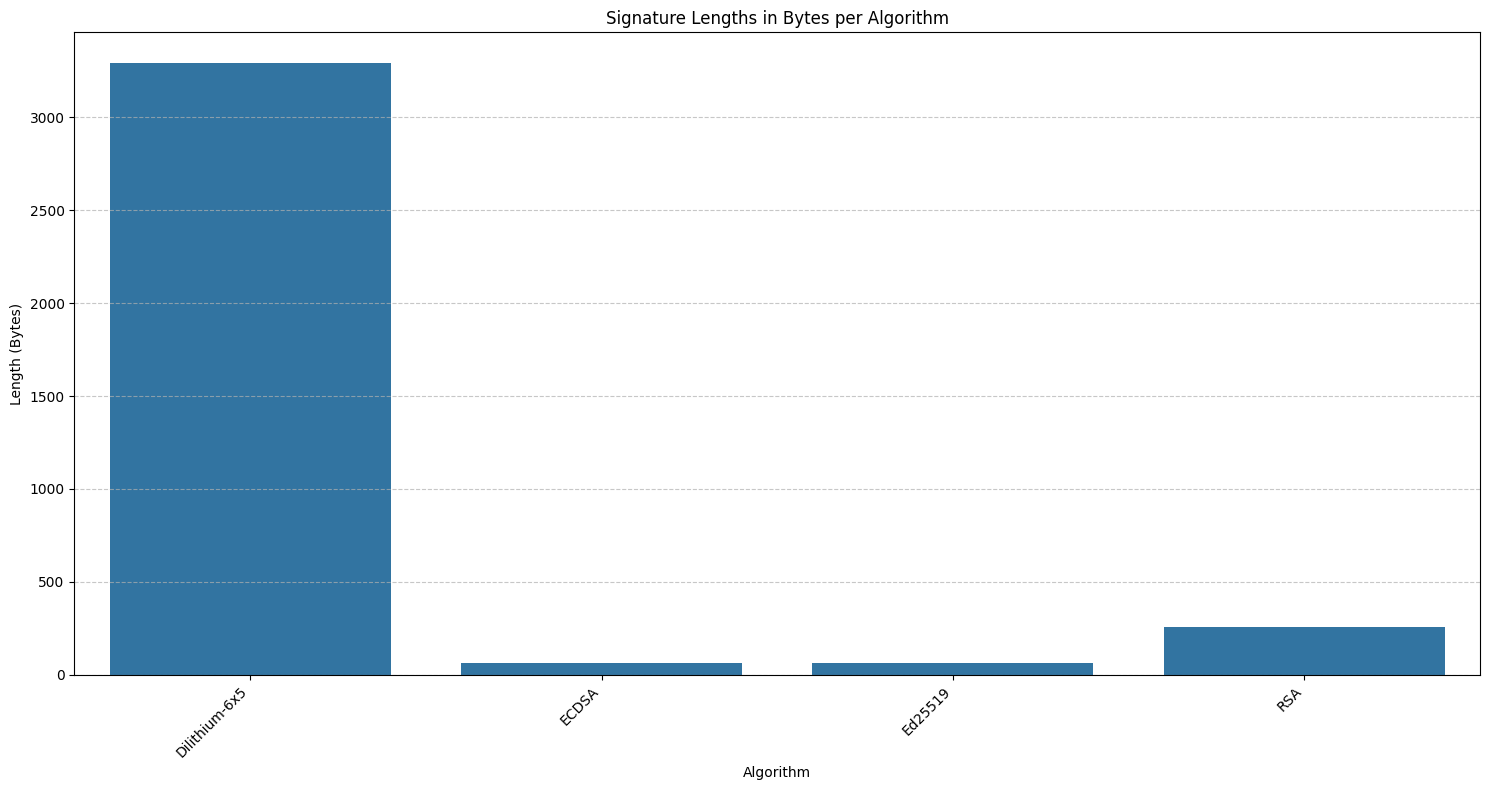

In [20]:
plot_key_length_comparison(df_signing_L3, "signature")

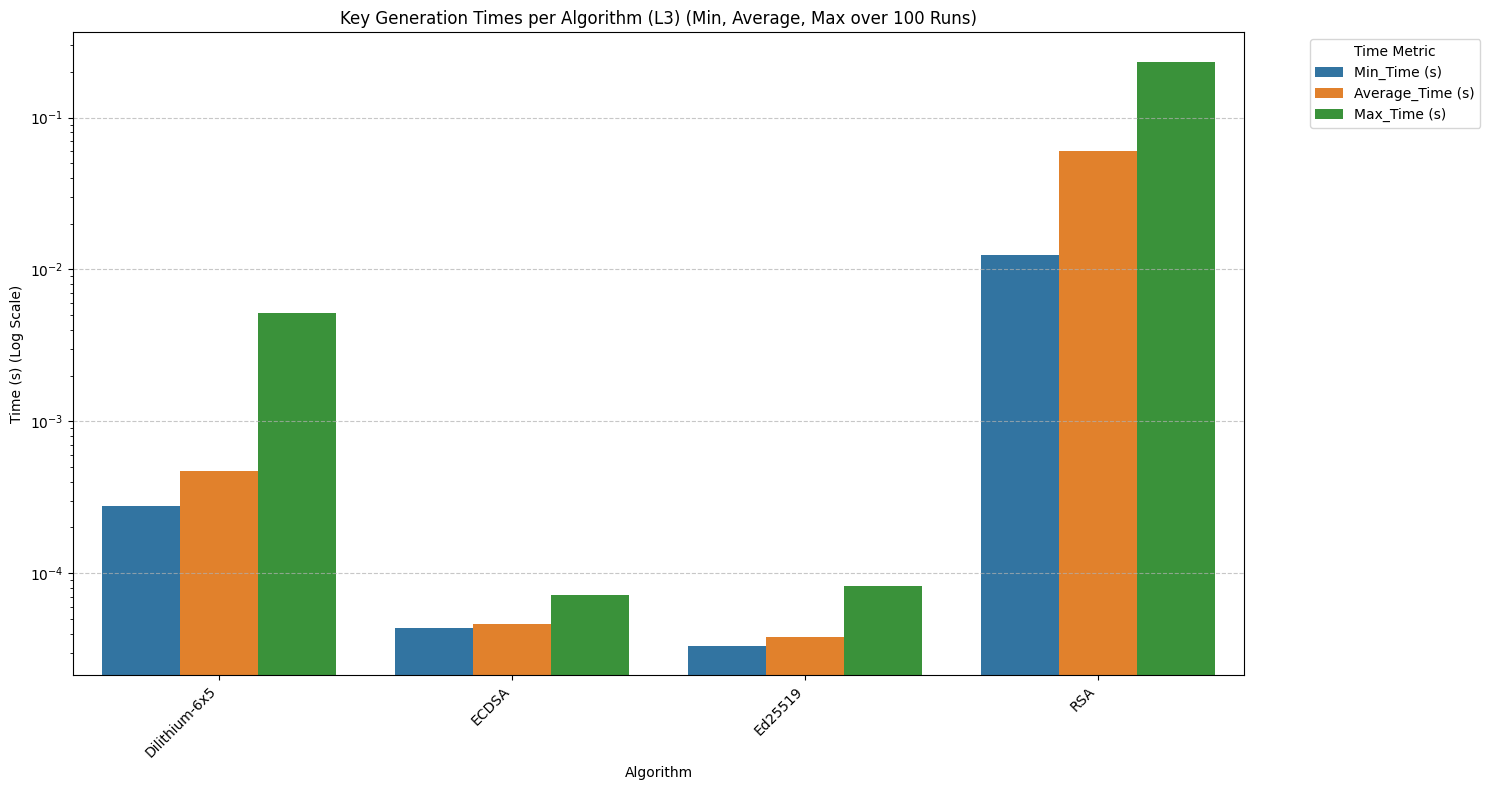

In [21]:
plot_timing_comparison(df_time_keys_L3, test_runs, "Key Generation", 3)

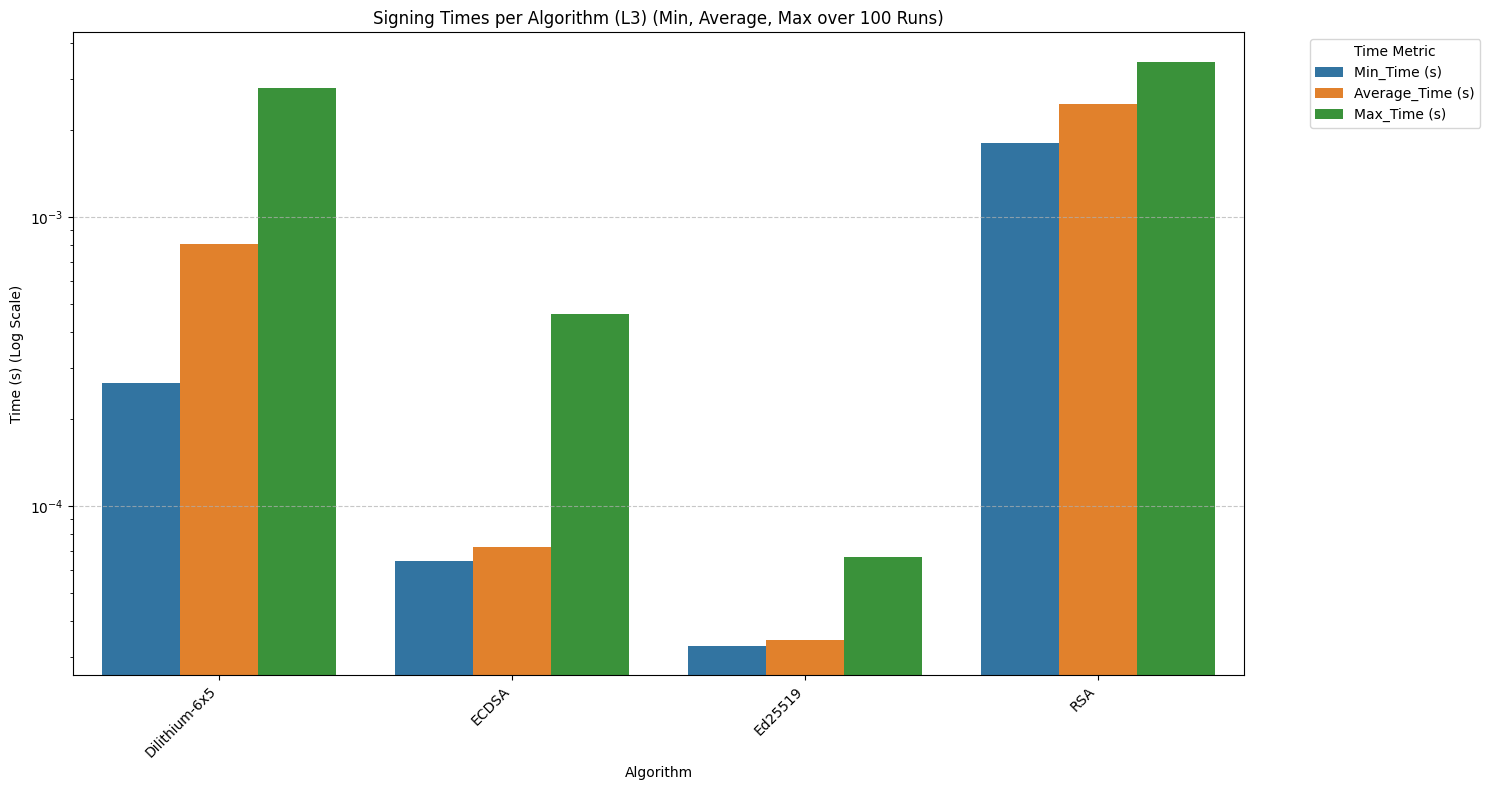

In [22]:
plot_timing_comparison(df_time_signing_L3, test_runs, "Signing", 3)

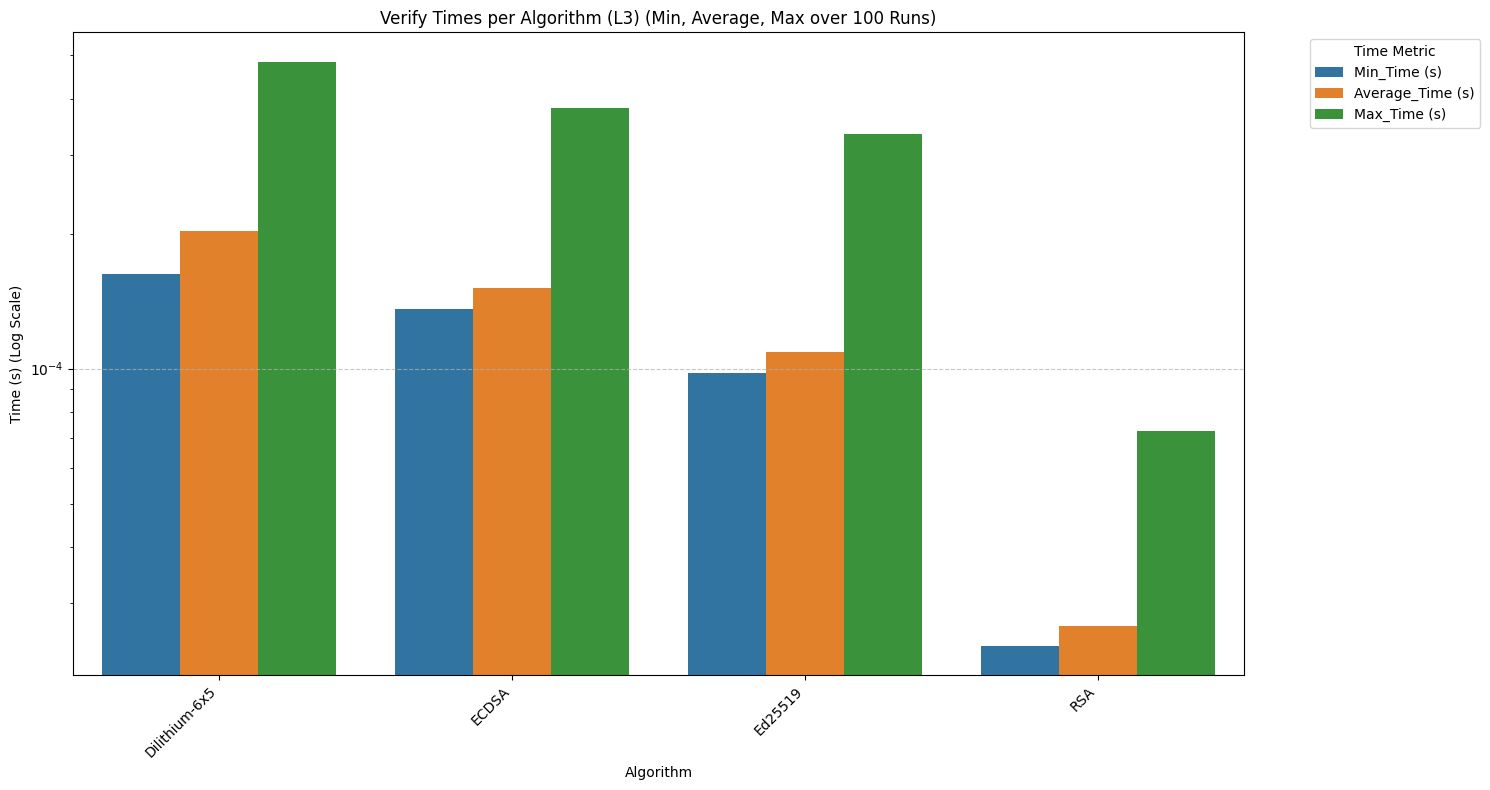

In [23]:
plot_timing_comparison(df_time_verify_L3, test_runs, "Verify", 3)

### Level 5 <a id="l5"></a>

In [24]:
print("\nLevel 5...")
df_keys_L5, df_time_keys_L5, df_signing_L5, df_time_signing_L5, df_verify_L5, df_time_verify_L5 = process_signing_level(signature_L5, test_runs, "L5")


Level 5...


In [25]:
display_results("L5", df_keys_L5, "Generated Keys")
display_results("L5", df_time_keys_L5, "Average Key Generation Times")


--- Generated Keys (L5) ---
       Algorithm Security Level  \
0  Dilithium-8x7             L5   
1        HSS-LMS             L5   
2            RSA             L5   
3          ECDSA             L5   
4        Ed25519             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [26]:
display_results("L5", df_signing_L5, "Signing Data")
display_results("L5", df_time_signing_L5, "Average Signing Times")


--- Signing Data (L5) ---
       Algorithm Security Level              Message (plain)  Message length  \
0  Dilithium-8x7             L5  This is the message to sign              27   
1        HSS-LMS             L5  This is the message to sign              27   
2            RSA             L5  This is the message to sign              27   
3          ECDSA             L5  This is the message to sign              27   
4        Ed25519             L5  This is the message to sign              27   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [27]:
display_results("L5", df_verify_L5, "Verify Data")
display_results("L5", df_time_verify_L5, "Average Verify Times")


--- Verify Data (L5) ---
       Algorithm Security Level  Is Valid
0  Dilithium-8x7             L5      True
1        HSS-LMS             L5      True
2            RSA             L5      True
3          ECDSA             L5      True
4        Ed25519             L5      True

--- Average Verify Times (L5) ---
       Algorithm Security Level Operation  Min_Time (s)  Average_Time (s)  \
0  Dilithium-8x7             L5    Verify      0.000162          0.000176   
1        HSS-LMS             L5    Verify      0.000029          0.000033   
2            RSA             L5    Verify      0.000027          0.000028   
3          ECDSA             L5    Verify      0.000144          0.000158   
4        Ed25519             L5    Verify      0.000107          0.000114   

   Max_Time (s)  
0      0.000284  
1      0.000058  
2      0.000088  
3      0.000518  
4      0.000392  


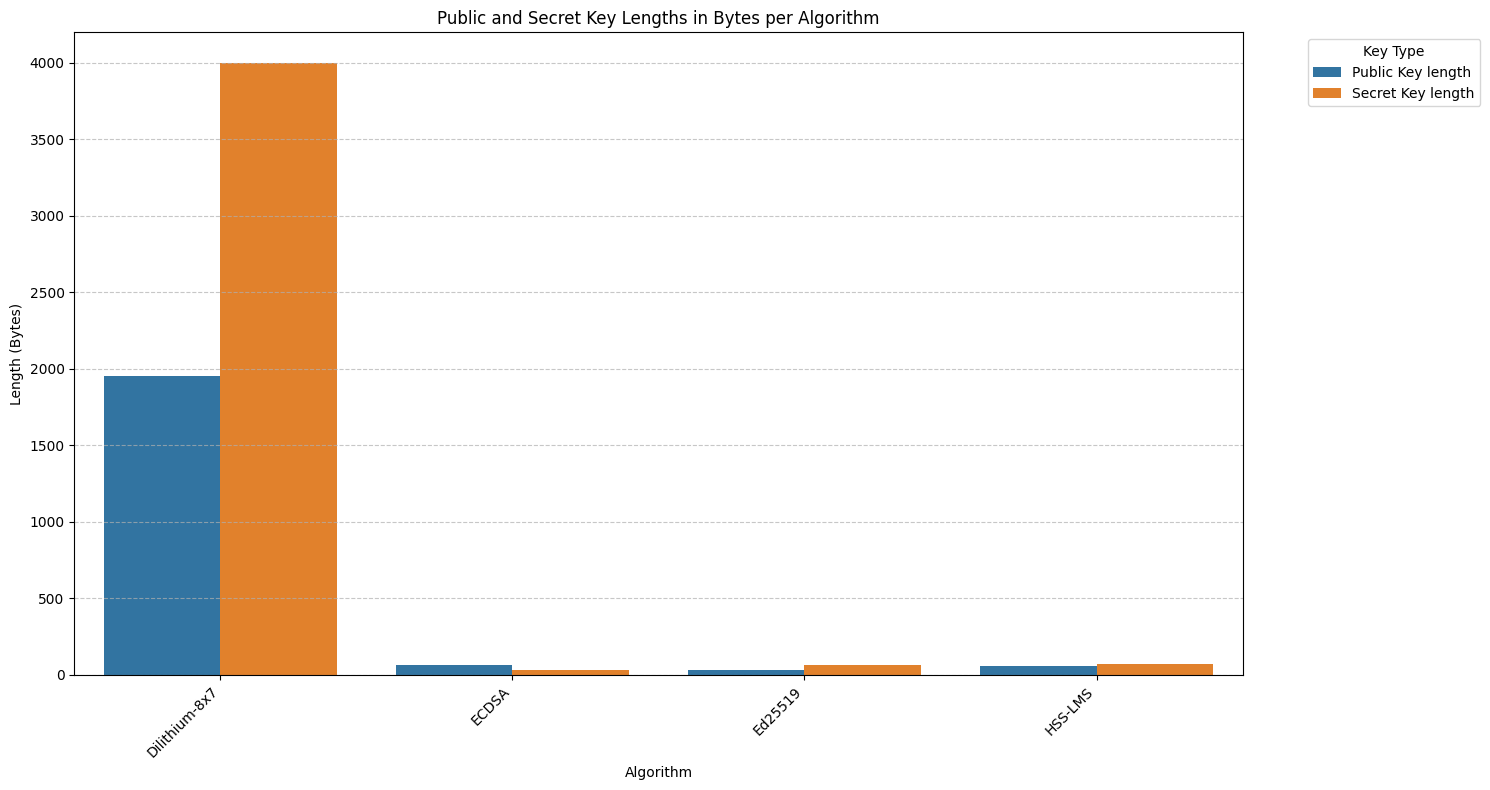

In [28]:
plot_key_length_comparison(df_keys_L5)

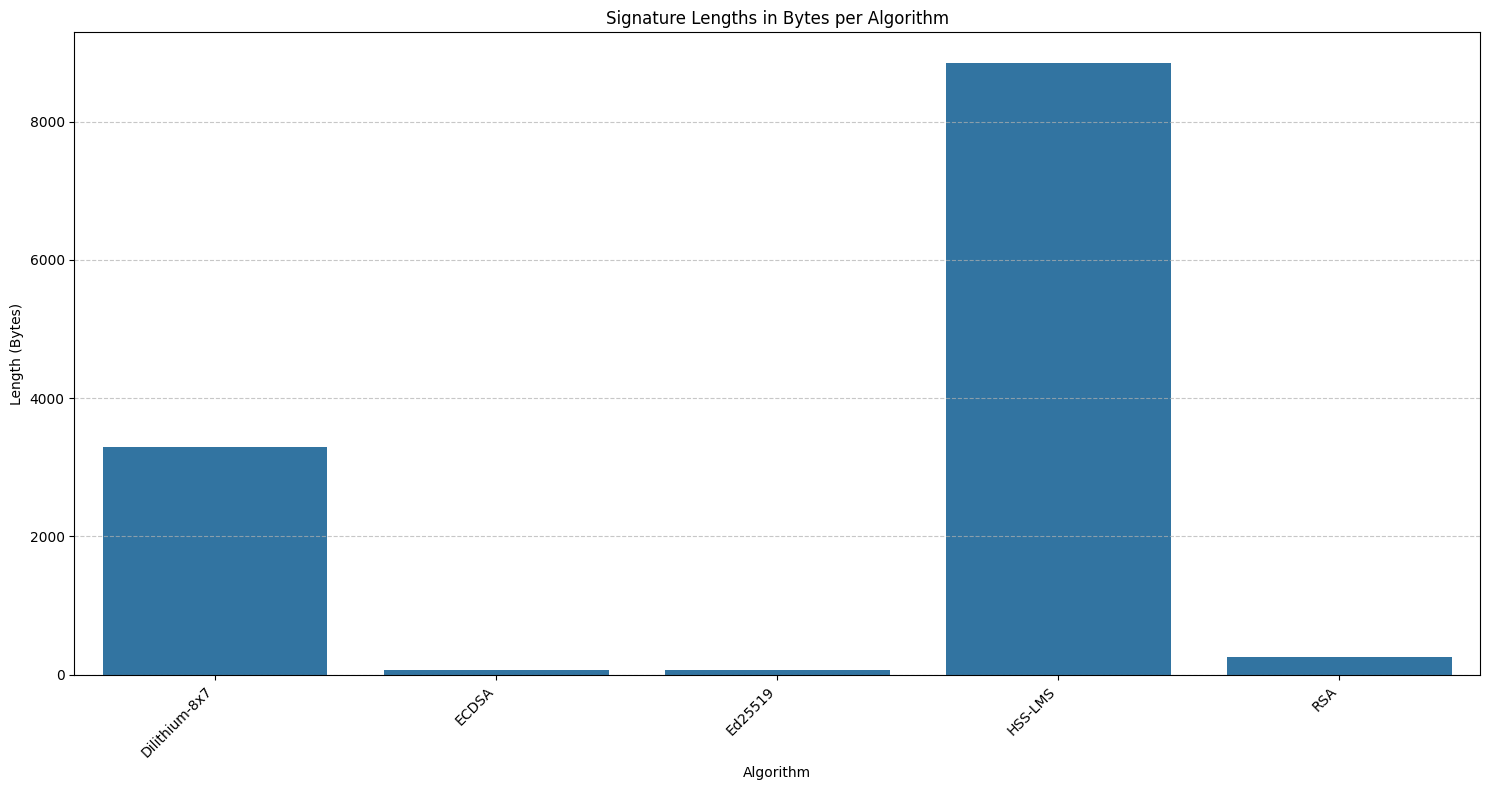

In [29]:
plot_key_length_comparison(df_signing_L5, "signature")

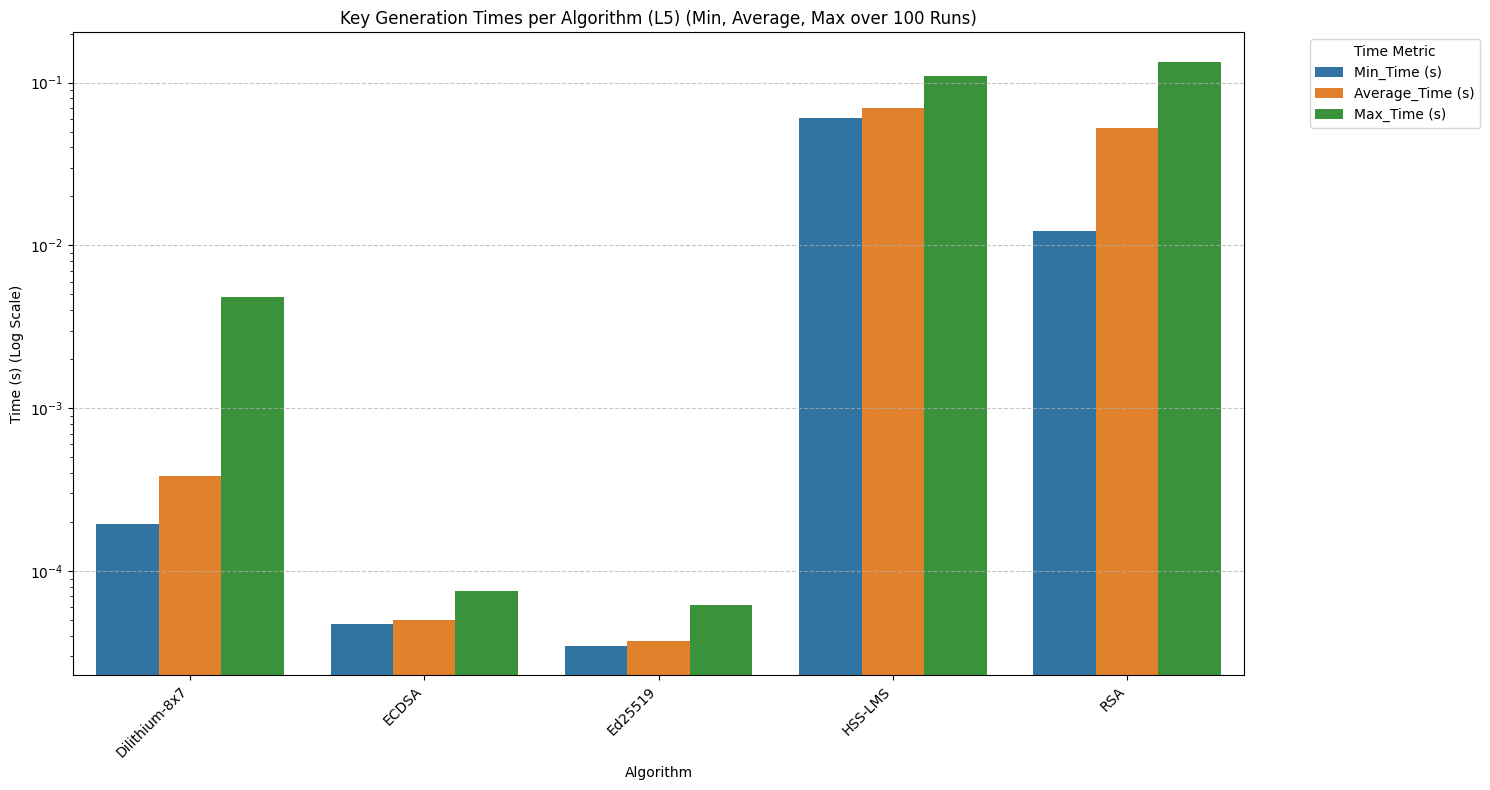

In [30]:
plot_timing_comparison(df_time_keys_L5, test_runs, "Key Generation", 5)

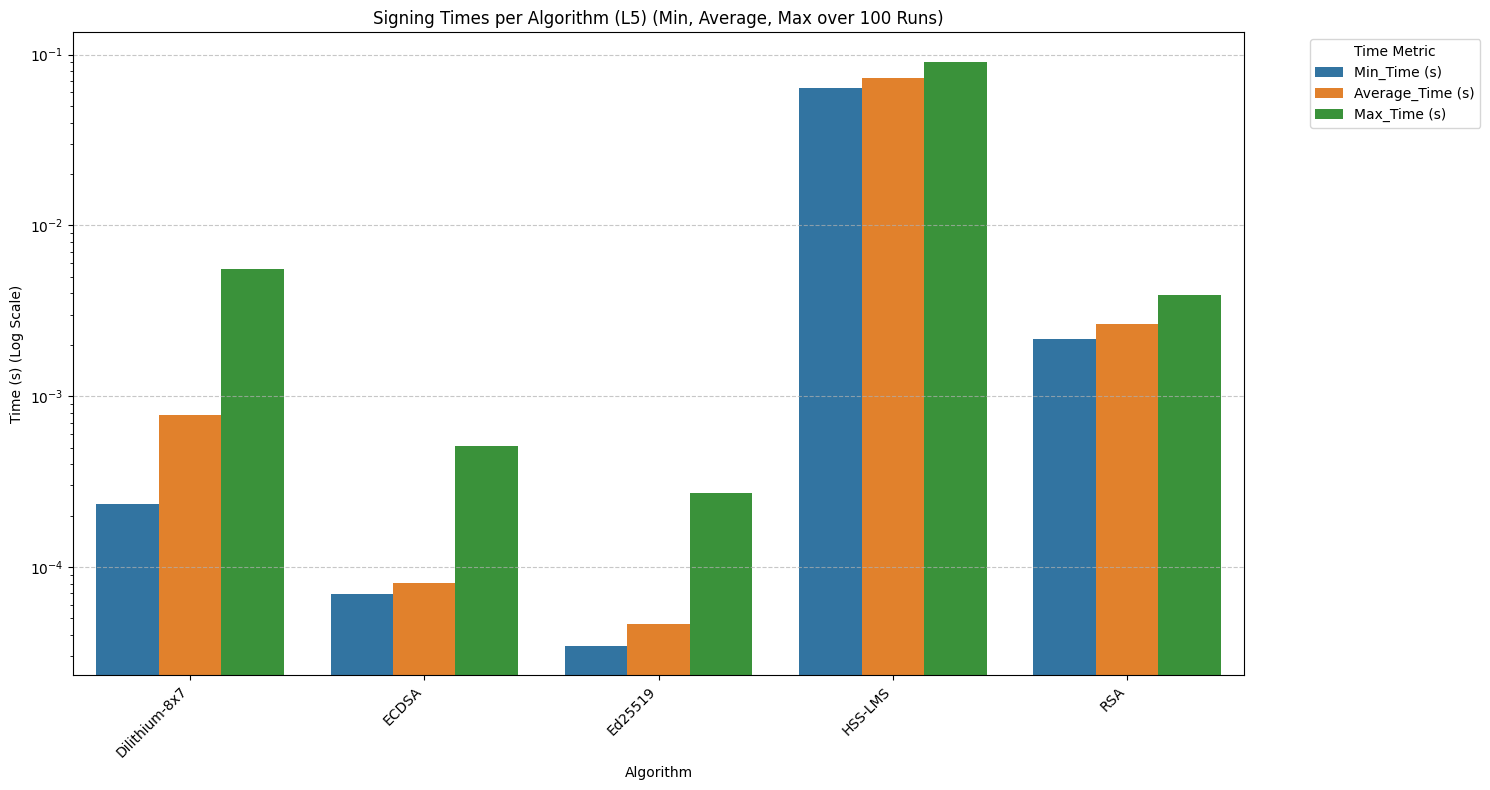

In [31]:
plot_timing_comparison(df_time_signing_L5, test_runs, "Signing", 5)

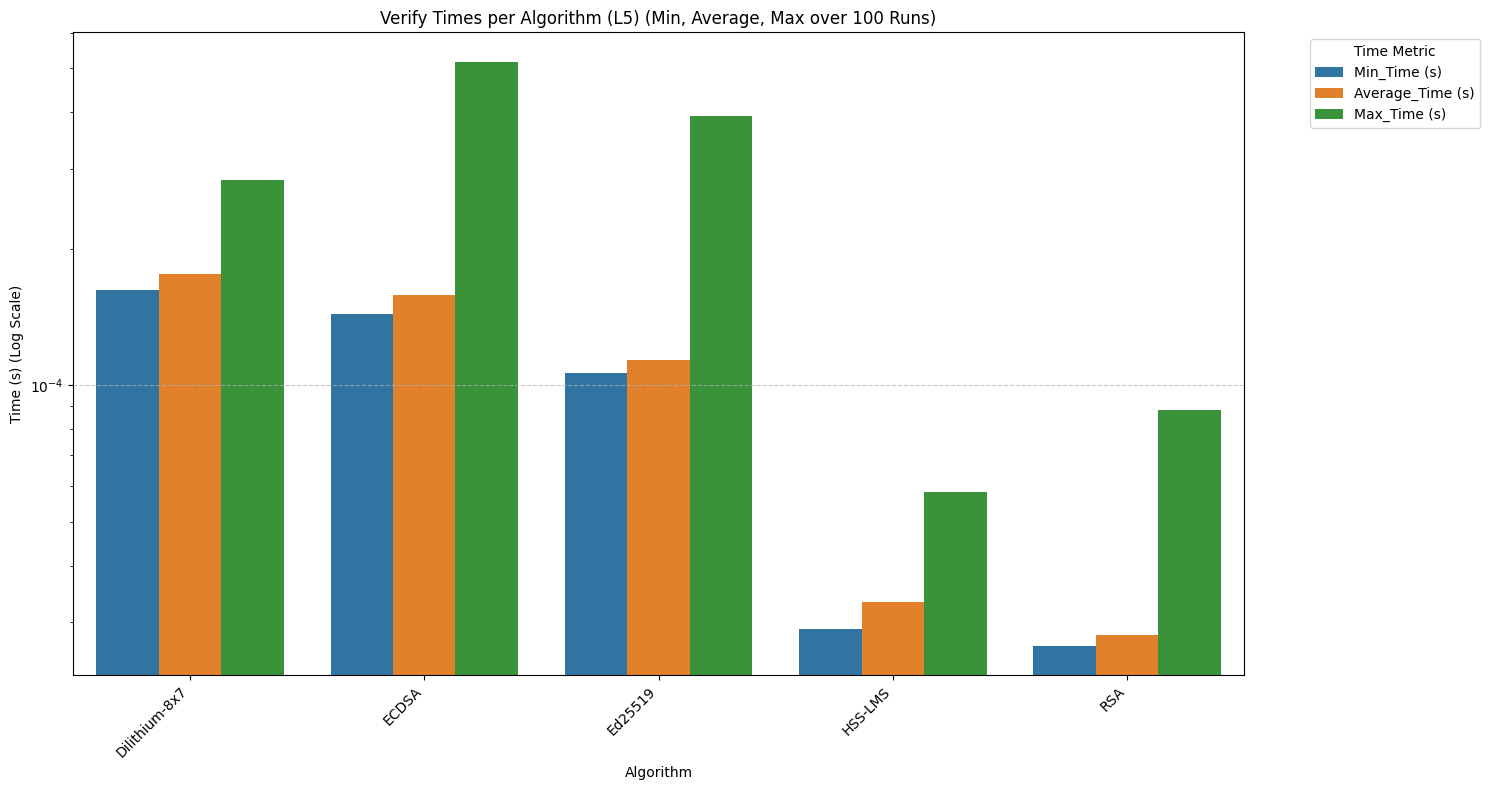

In [32]:
plot_timing_comparison(df_time_verify_L5, test_runs, "Verify", 5)

## Conclusion <a id="conclusion"></a>

All algorithms show extremely **diverse performance** values for key generation, signing, and verification. To gain a comprehensive overview of the time taken, we will therefore sum the individual operation times for each algorithm.

Unlike KEMs (Key Encapsulation Mechanisms), where one algorithm might consistently outperform others across all operations, the choice of algorithm here is highly dependent on **specific requirements**. There's no single "best" algorithm; instead, the optimal choice will be dictated by which operations are most critical for the particular application.

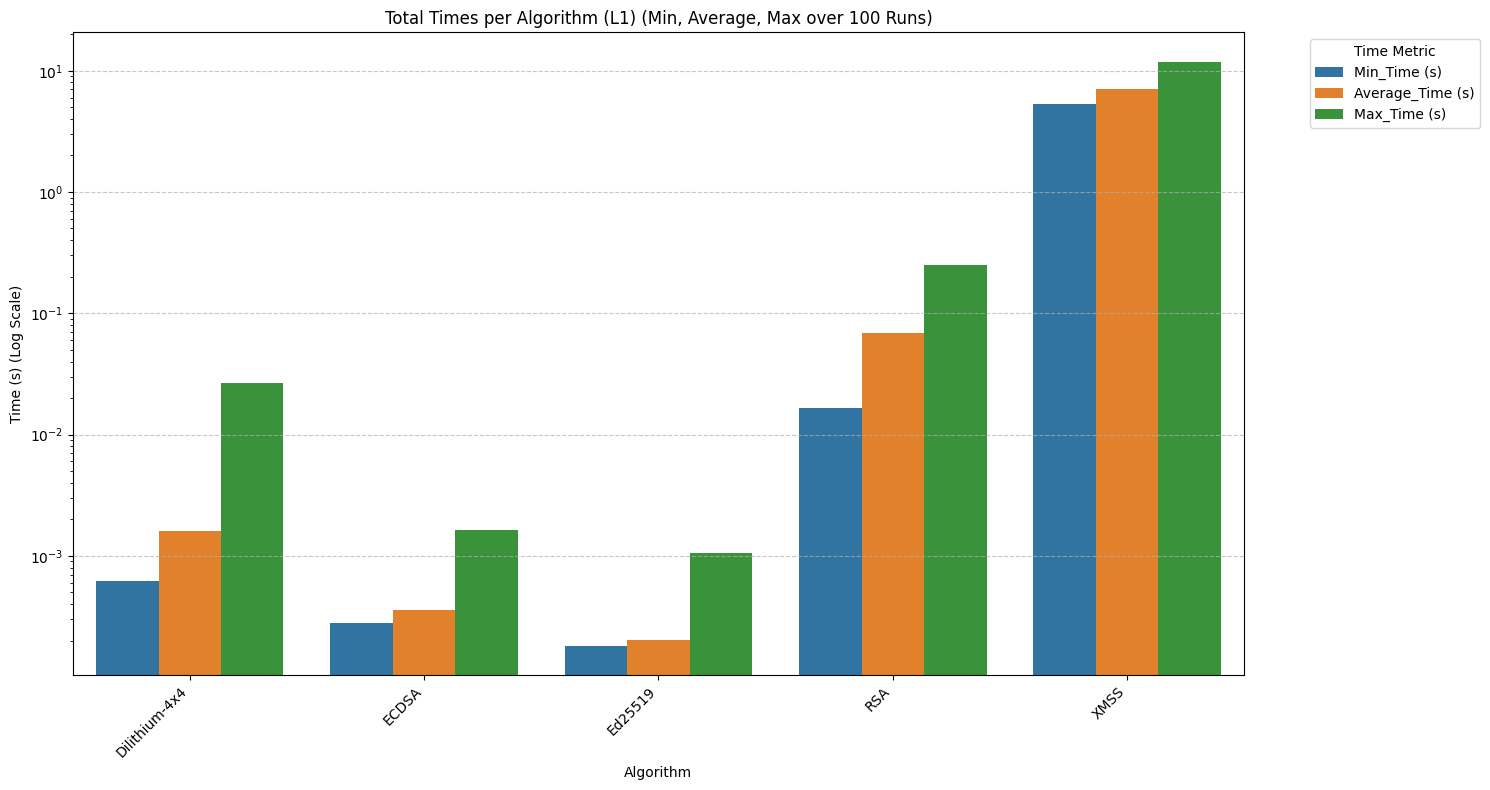

In [33]:
all_dfs_L1 = [df_time_keys_L1, df_time_signing_L1, df_time_verify_L1]
total_times_L1 = pd.concat(all_dfs_L1, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L1, test_runs, "Total", 1)

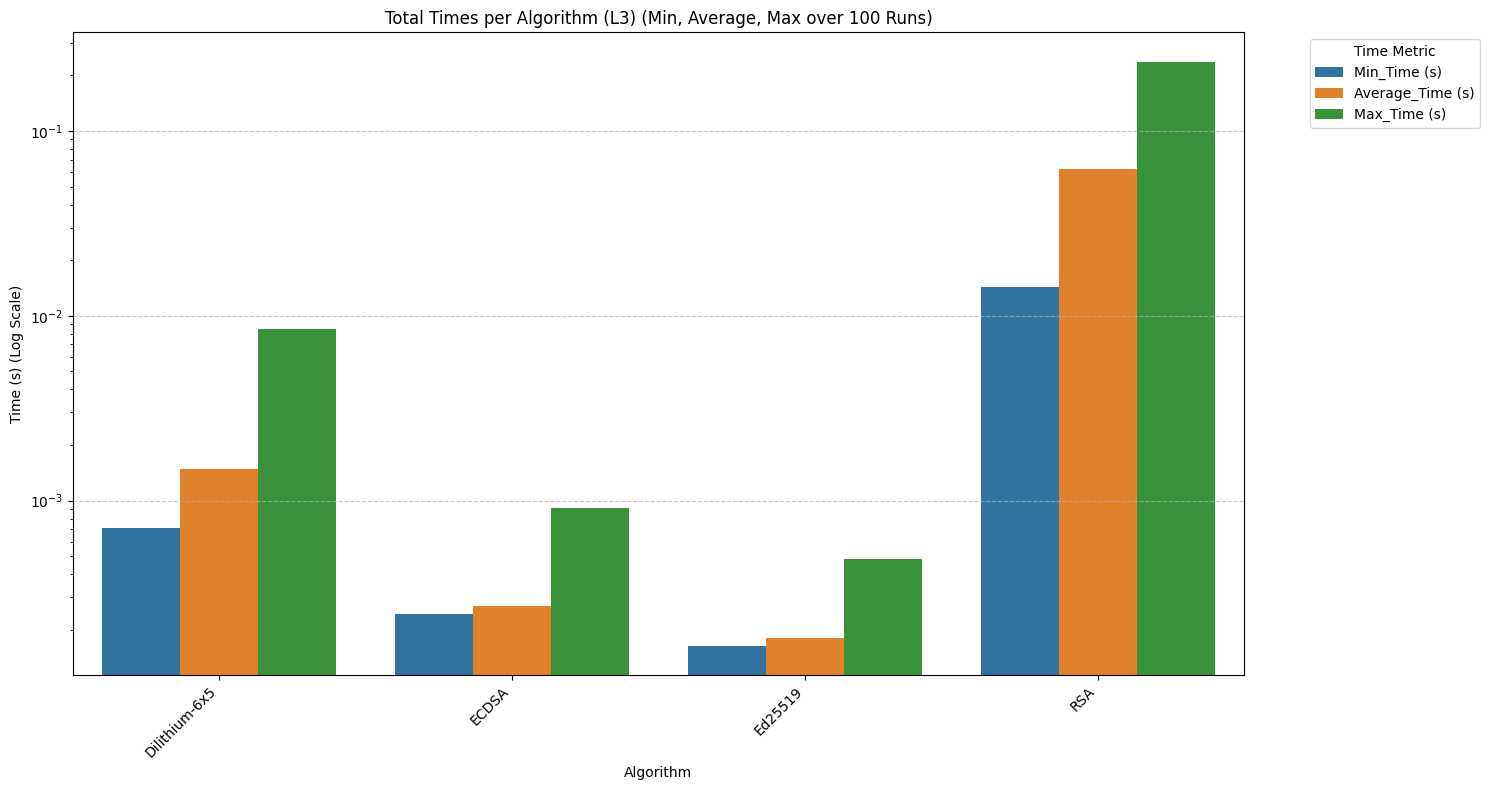

In [34]:
all_dfs_L3 = [df_time_keys_L3, df_time_signing_L3, df_time_verify_L3]
total_times_L3 = pd.concat(all_dfs_L3, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L3, test_runs, "Total", 3)

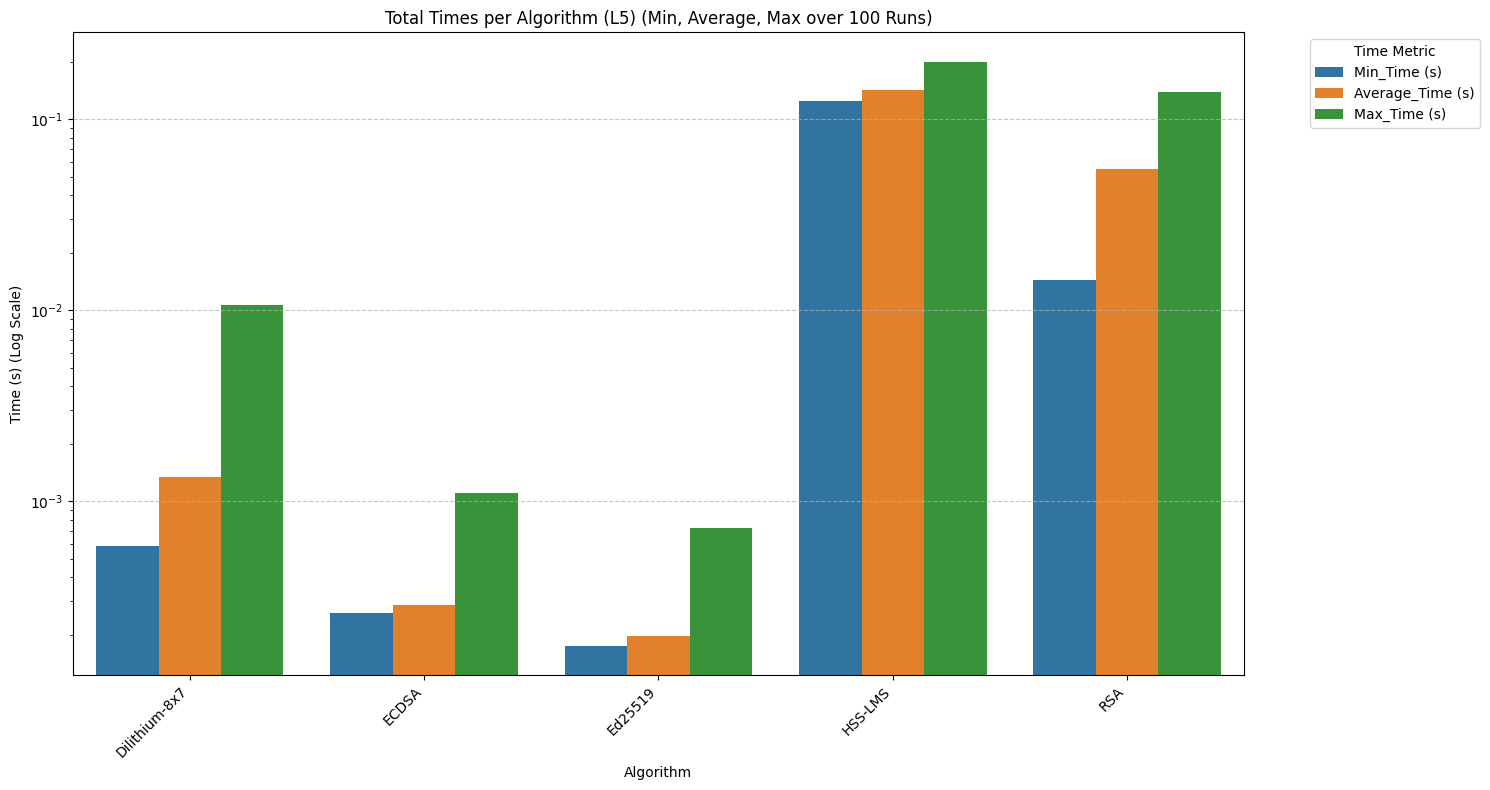

In [35]:
all_dfs_L5 = [df_time_keys_L5, df_time_signing_L5, df_time_verify_L5]
total_times_L5 = pd.concat(all_dfs_L5, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L5, test_runs, "Total", 5)

The performance comparison reveals important trade-offs between these algorithms. Post-quantum algorithms generally have larger key sizes and signatures, with Dilithium showing the best performance among the post-quantum options. Traditional algorithms like Ed25519 still offer superior performance but won't be secure against quantum computers. This benchmark provides valuable insights for choosing the right signature algorithm based on specific application requirements and security needs.